# Predicción multihorizonte de la potencia de un molino de bolas mediante XGBoost

**Trabajo Fin de Máster — Máster Universitario en Big Data y Ciencia de Datos**  
**Autor:** Jordan Gómez Espinoza  
**Modelo:** Extreme Gradient Boosting (XGBoost)  
**Versión del experimento:** 1.1 — horizonte completamente parametrizable

Este notebook implementa un experimento reproducible para pronosticar la trayectoria de potencia activa (`POT`) durante el horizonte definido en la configuración única, a partir del contexto histórico indicado por `WINDOW`. Se adopta una estrategia directa: se entrena automáticamente un regresor independiente para cada uno de los `HORIZON` instantes futuros.

> **Confidencialidad.** El análisis identifica el equipo únicamente como molino de bolas 1D. El archivo industrial no debe publicarse; el código, la configuración y los resultados agregados sí pueden incorporarse al TFM.


## Contrato experimental común a TFT, XGBoost y ARIMAX

| Elemento | Decisión metodológica |
|---|---|
| Datos originales | 444.580 mediciones reales cada 5 s |
| Agregación | Media de tres mediciones reales por intervalo completo de 15 s |
| Dataset final | 148.193 observaciones completas, sin imputar el objetivo |
| Objetivo | `POT` (MW) |
| Información histórica | `POT`, `F80`, `T`, `AA`, `AD` |
| Ventana de entrada | Derivada de `WINDOW` y `MODEL_FREQ` |
| Horizonte | Derivado de `HORIZON` y `MODEL_FREQ` |
| División | 113.633 observaciones de entrenamiento, 17.280 de validación (3 días) y 17.280 de prueba (3 días) |
| Evaluación | *Rolling origin* con avance `ROLLING_STRIDE` |
| Referencia | Persistencia del último valor de `POT` observado |

La validación se utiliza para la parada temprana. El test se mantiene reservado hasta la evaluación final. Las historias de validación y prueba contienen únicamente observaciones reales anteriores al origen; nunca incluyen datos posteriores al instante del pronóstico.


## 1. Entorno de ejecución

El notebook está preparado para XGBoost moderno y selecciona GPU automáticamente cuando está disponible; en caso contrario utiliza CPU. Para preparar un entorno limpio puede ejecutarse, una sola vez y antes de la corrida oficial:

```bash
pip install "xgboost>=2.0,<4" pandas numpy scikit-learn matplotlib seaborn joblib
```

Tras la instalación se debe reiniciar el kernel. La corrida oficial debe realizarse de principio a fin sin modificar celdas ni ajustar parámetros a partir del test.


In [1]:
# ============================================================
# 1. IMPORTACIONES GENERALES Y CONFIGURACIÓN VISUAL
# ============================================================

import hashlib
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    r2_score,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})


In [2]:
# ============================================================
# 2. CONFIGURACIÓN ÚNICA DEL EXPERIMENTO
# ============================================================

DATE_COL = "FECHA"
TARGET = "POT"
PAST_COVARS = ["F80", "T", "AA", "AD"]
INPUT_COLS = [TARGET] + PAST_COVARS
REQUIRED_COLS = [DATE_COL] + PAST_COVARS + [TARGET]

CSV_FILENAME = "1D_POT_2.csv"
CSV_SEPARATOR = ","
DATE_FORMAT = "%d/%m/%Y %H:%M:%S"
RAW_FREQ = "5s"
MODEL_FREQ = "15s"
RAW_POINTS_PER_MODEL_BIN = 3

WINDOW = 120                  # 120 × 15 s = 30 min
HORIZON = 60                  # 60 × 15 s = 15 min; puede modificarse aquí
ROLLING_STRIDE = HORIZON      # trayectorias no solapadas
VAL_DAYS = 3
TEST_DAYS = 3

N_ESTIMATORS = 1_200
LEARNING_RATE = 0.03
MAX_DEPTH = 6
MIN_CHILD_WEIGHT = 5
SUBSAMPLE = 0.80
COLSAMPLE_BYTREE = 0.80
REG_ALPHA = 0.01
REG_LAMBDA = 1.0
GAMMA = 0.0
EARLY_STOPPING_ROUNDS = 50
N_JOBS = -1
USE_GPU = "auto"

TRAIN_SAMPLE_STRIDE = 1
PERMUTATION_REPEATS = 5
BOOTSTRAP_REPETITIONS = 2_000
INTERVAL_QUANTILES = (0.10, 0.90)
POWER_DANGER_THRESHOLD = 2.28
SEED = 42

EXPECTED_RAW_ROWS = 444_580
EXPECTED_MODEL_ROWS = 148_193
EXPECTED_SHA256 = ("13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1")
STRICT_DATASET_VALIDATION = True

MODEL_STEP_SECONDS = float(pd.Timedelta(MODEL_FREQ).total_seconds())
WINDOW_MINUTES = WINDOW * MODEL_STEP_SECONDS / 60.0
HORIZON_MINUTES = HORIZON * MODEL_STEP_SECONDS / 60.0
ROLLING_STRIDE_MINUTES = ROLLING_STRIDE * MODEL_STEP_SECONDS / 60.0
HORIZON_LABEL = f"{HORIZON_MINUTES:g}"
HORIZON_TAG = HORIZON_LABEL.replace(".", "p") + "min"

assert WINDOW > 0
assert HORIZON > 0
assert ROLLING_STRIDE > 0
assert TRAIN_SAMPLE_STRIDE > 0

ARTIFACT_DIR = Path(f"resultados_xgboost_{HORIZON_TAG}_final")
MODEL_DIR = ARTIFACT_DIR / "modelos"
FIGURE_DIR = ARTIFACT_DIR / "figuras"
TABLE_DIR = ARTIFACT_DIR / "tablas"
for folder in (ARTIFACT_DIR, MODEL_DIR, FIGURE_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Ventana: {WINDOW} pasos = {WINDOW_MINUTES:g} min")
print(f"Horizonte: {HORIZON} pasos = {HORIZON_MINUTES:g} min")
print(f"Avance rolling: {ROLLING_STRIDE} pasos = {ROLLING_STRIDE_MINUTES:g} min")
print(f"Artefactos: {ARTIFACT_DIR.resolve()}")


Ventana: 120 pasos = 30 min
Horizonte: 60 pasos = 15 min
Avance rolling: 60 pasos = 15 min
Artefactos: C:\Users\jgomeze\Documents\woody\Py\resultados_xgboost_15min_final


## 2. Ingesta, auditoría y agregación temporal

Las siguientes celdas son deliberadamente estrictas. Verifican identidad del archivo, esquema, cronología, frecuencia, valores no finitos y límites físicos básicos. La agregación conserva únicamente intervalos con tres observaciones reales; no se usa relleno hacia delante, interpolación ni eliminación automática de duplicados.


In [3]:
# ============================================================
# 3. LOCALIZACIÓN E IDENTIDAD DEL ARCHIVO
# ============================================================

def localizar_csv(filename):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/content") / filename,
        Path("/kaggle/working") / filename,
        Path("upload") / filename,
        Path("../upload") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No se encontró {filename}. Colóquelo junto al notebook o actualice CSV_FILENAME."
    )

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

CSV_PATH = localizar_csv(CSV_FILENAME)
DATASET_SHA256 = sha256_file(CSV_PATH)
print("CSV:", CSV_PATH)
print("SHA-256:", DATASET_SHA256)
if STRICT_DATASET_VALIDATION:
    assert DATASET_SHA256 == EXPECTED_SHA256, "El archivo no coincide con el dataset auditado."


CSV: C:\Users\jgomeze\Documents\woody\Py\1D_POT_2.csv
SHA-256: 13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1


In [4]:
# ============================================================
# 4. LECTURA Y AUDITORÍA DEL CSV CRUDO
# ============================================================

raw = pd.read_csv(CSV_PATH, sep=CSV_SEPARATOR)
assert list(raw.columns) == REQUIRED_COLS, f"Columnas inesperadas: {list(raw.columns)}"
assert len(raw) == EXPECTED_RAW_ROWS, f"Filas crudas: {len(raw):,}"

parsed_dates = pd.to_datetime(raw[DATE_COL], format=DATE_FORMAT, errors="coerce")
assert parsed_dates.notna().all(), "Existen fechas no interpretables."
raw[DATE_COL] = parsed_dates

numeric_cols = PAST_COVARS + [TARGET]
for column in numeric_cols:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

audit_raw = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "unicos": raw.nunique(dropna=True),
})
display(audit_raw)

assert raw[numeric_cols].notna().all().all(), "Hay valores numéricos ausentes o inválidos."
assert np.isfinite(raw[numeric_cols].to_numpy(dtype=float)).all(), "Hay infinitos."
assert raw[DATE_COL].is_monotonic_increasing, "La cronología no es creciente."
assert not raw[DATE_COL].duplicated().any(), "Existen timestamps duplicados."

raw_deltas = raw[DATE_COL].diff().dropna()
delta_counts = raw_deltas.value_counts().rename_axis("delta").to_frame("conteo")
display(delta_counts.head(10))
assert raw_deltas.eq(pd.Timedelta(RAW_FREQ)).all(), "La frecuencia cruda no es exactamente 5 s."

print(f"Periodo crudo: {raw[DATE_COL].min()} — {raw[DATE_COL].max()}")
print(f"Filas crudas: {len(raw):,}")
display(raw[numeric_cols].describe().T)


,dtype,nulos,unicos
FECHA,datetime64[ns],0,444580
F80,float64,0,337745
T,float64,0,341555
AA,float64,0,412111
AD,float64,0,420420
POT,float64,0,280012


,conteo
delta,
0 days 00:00:05,444579


Periodo crudo: 2026-08-01 14:45:00 — 2026-08-27 08:13:15
Filas crudas: 444,580


,count,mean,std,min,25%,50%,75%,max
F80,"444,580.000000","6,818.917272",879.605916,0.000000,"6,467.866699","6,744.128662","7,074.821533","10,382.029300"
T,"444,580.000000",272.198056,19.631657,0.205997,262.432564,276.286972,284.679634,313.106445
AA,"444,580.000000","2,297.236965",355.756651,746.734558,"2,031.433075","2,310.303833","2,529.837219","3,742.961914"
AD,"444,580.000000","5,048.962904",636.610770,"3,309.231934","4,572.738038","4,958.445068","5,599.362183","6,776.545898"
POT,"444,580.000000",2.312818,0.030195,2.229558,2.288449,2.307366,2.336656,2.443580


In [5]:
# ============================================================
# 5. AGREGACIÓN 5 s -> 15 s SIN IMPUTACIÓN
# ============================================================

raw_ts = raw.set_index(DATE_COL)[numeric_cols].sort_index()
grouped = raw_ts.resample(MODEL_FREQ, origin=raw_ts.index[0])
bin_counts = grouped.count()
bin_means = grouped.mean()
complete_mask = bin_counts.eq(RAW_POINTS_PER_MODEL_BIN).all(axis=1)

incomplete_bins = bin_counts.loc[~complete_mask]
print(f"Intervalos incompletos excluidos: {len(incomplete_bins):,}")
if len(incomplete_bins):
    display(incomplete_bins)

df = bin_means.loc[complete_mask].copy()
df.index.name = DATE_COL

assert len(df) == EXPECTED_MODEL_ROWS, f"Filas a 15 s: {len(df):,}"
assert df.index.is_monotonic_increasing and df.index.is_unique
assert df.index.to_series().diff().dropna().eq(pd.Timedelta(MODEL_FREQ)).all()
assert df[numeric_cols].notna().all().all()
assert np.isfinite(df[numeric_cols].to_numpy(dtype=float)).all()

dataset_audit = {
    "csv_path": str(CSV_PATH),
    "sha256": DATASET_SHA256,
    "raw_rows": int(len(raw)),
    "model_rows": int(len(df)),
    "incomplete_bins_excluded": int((~complete_mask).sum()),
    "start": str(df.index.min()),
    "end": str(df.index.max()),
    "raw_frequency": RAW_FREQ,
    "model_frequency": MODEL_FREQ,
    "imputation": "none",
}
print(json.dumps(dataset_audit, indent=2, ensure_ascii=False))
display(df.head())


Intervalos incompletos excluidos: 1


,F80,T,AA,AD,POT
FECHA,,,,,
2026-08-27 08:13:15,1,1,1,1,1


{
  "csv_path": "C:\\Users\\jgomeze\\Documents\\woody\\Py\\1D_POT_2.csv",
  "sha256": "13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1",
  "raw_rows": 444580,
  "model_rows": 148193,
  "incomplete_bins_excluded": 1,
  "start": "2026-08-01 14:45:00",
  "end": "2026-08-27 08:13:00",
  "raw_frequency": "5s",
  "model_frequency": "15s",
  "imputation": "none"
}


,F80,T,AA,AD,POT
FECHA,,,,,
2026-08-01 14:45:00,"5,937.019857",259.124044,"2,182.784993","5,957.765137",2.364779
2026-08-01 14:45:15,"5,934.916504",258.904917,"2,183.043701","5,907.456706",2.364624
2026-08-01 14:45:30,"5,932.813314",258.674642,"2,183.302490","5,908.003907",2.364469
2026-08-01 14:45:45,"5,930.709961",258.435557,"2,183.561279","5,896.214355",2.364313
2026-08-01 14:46:00,"5,928.606608",258.196462,"2,183.819987","5,907.605794",2.364158


,min,max,mean,std,n_negative
F80,0.000001,"10,382.029300","6,818.918611",879.575286,0
T,0.205997,312.996562,272.198056,19.628678,0
AA,749.931763,"3,314.998779","2,297.235466",355.688533,0
AD,"3,330.113525","6,744.123047","5,048.966270",635.486513,0
POT,2.229676,2.443293,2.312818,0.030194,0


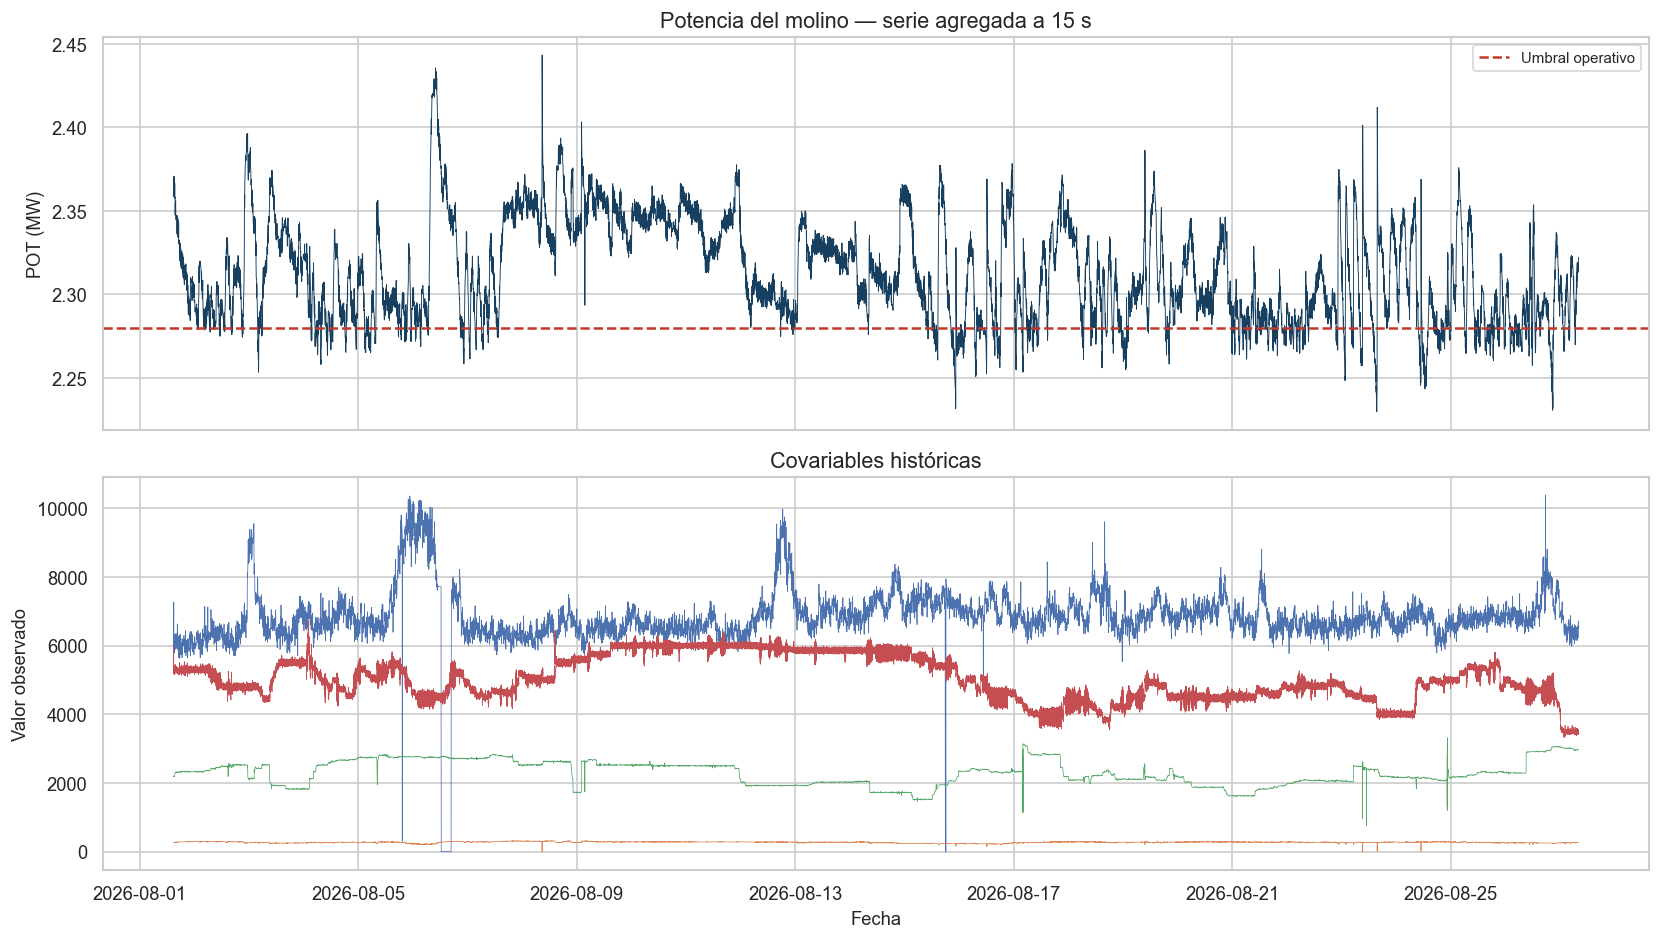

In [6]:
# ============================================================
# 6. CONTROL DE RANGOS Y VISUALIZACIÓN DESCRIPTIVA
# ============================================================

physical_checks = pd.DataFrame({
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "mean": df[numeric_cols].mean(),
    "std": df[numeric_cols].std(),
    "n_negative": (df[numeric_cols] < 0).sum(),
})
display(physical_checks)
assert (df[numeric_cols] >= 0).all().all(), "Se detectaron valores negativos; revisar con planta."

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df[TARGET], linewidth=0.55, color="#173F5F")
axes[0].axhline(POWER_DANGER_THRESHOLD, color="#C0392B", linestyle="--", label="Umbral operativo")
axes[0].set_ylabel("POT (MW)")
axes[0].set_title("Potencia del molino — serie agregada a 15 s")
axes[0].legend()
axes[1].plot(df.index, df[PAST_COVARS], linewidth=0.45)
axes[1].set_ylabel("Valor observado")
axes[1].set_xlabel("Fecha")
axes[1].set_title("Covariables históricas")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_series_temporales.png", bbox_inches="tight")
plt.show()


## 3. División temporal y formulación supervisada

El orden temporal se mantiene en todo momento. Se reservan los últimos tres días para prueba y los tres anteriores para validación. Cada fila de entrada concatena `WINDOW` vectores históricos; cada salida contiene `HORIZON` valores futuros. El número de orígenes, las dimensiones y la cobertura efectiva se calculan automáticamente.


In [7]:
# ============================================================
# 7. DIVISIÓN CRONOLÓGICA
# ============================================================

steps_per_day = int(pd.Timedelta(days=1) / pd.Timedelta(MODEL_FREQ))
VAL_LEN = VAL_DAYS * steps_per_day
TEST_LEN = TEST_DAYS * steps_per_day
TOTAL_LEN = len(df)
TRAIN_LEN = TOTAL_LEN - VAL_LEN - TEST_LEN

assert TRAIN_LEN > WINDOW + HORIZON
assert VAL_LEN >= HORIZON
assert TEST_LEN >= HORIZON
assert TRAIN_LEN + VAL_LEN + TEST_LEN == TOTAL_LEN

train_end = TRAIN_LEN
val_end = TRAIN_LEN + VAL_LEN

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

split_table = pd.DataFrame([
    {"particion": "train", "filas": len(train_df), "inicio": train_df.index.min(), "fin": train_df.index.max()},
    {"particion": "validation", "filas": len(val_df), "inicio": val_df.index.min(), "fin": val_df.index.max()},
    {"particion": "test", "filas": len(test_df), "inicio": test_df.index.min(), "fin": test_df.index.max()},
])
display(split_table)
assert train_df.index.max() < val_df.index.min() < test_df.index.min()


,particion,filas,inicio,fin
0,train,113633,2026-08-01 14:45:00,2026-08-21 08:13:00
1,validation,17280,2026-08-21 08:13:15,2026-08-24 08:13:00
2,test,17280,2026-08-24 08:13:15,2026-08-27 08:13:00


In [8]:
# ============================================================
# 8. ORÍGENES Y MATRICES SUPERVISADAS DINÁMICAS
# ============================================================

values_input = df[INPUT_COLS].to_numpy(dtype=np.float32)
values_target = df[TARGET].to_numpy(dtype=np.float32)
time_index = pd.DatetimeIndex(df.index)

train_origins = np.arange(WINDOW, TRAIN_LEN - HORIZON + 1, TRAIN_SAMPLE_STRIDE, dtype=np.int64)
val_origins = np.arange(TRAIN_LEN, val_end - HORIZON + 1, ROLLING_STRIDE, dtype=np.int64)
test_origins = np.arange(val_end, TOTAL_LEN - HORIZON + 1, ROLLING_STRIDE, dtype=np.int64)

def construir_X(origins):
    offsets = np.arange(-WINDOW, 0, dtype=np.int64)
    history = values_input[origins[:, None] + offsets[None, :]]
    return np.ascontiguousarray(history.reshape(len(origins), -1), dtype=np.float32)

def construir_Y(origins):
    offsets = np.arange(HORIZON, dtype=np.int64)
    return np.ascontiguousarray(values_target[origins[:, None] + offsets[None, :]], dtype=np.float32)

X_train, Y_train = construir_X(train_origins), construir_Y(train_origins)
X_val, Y_val = construir_X(val_origins), construir_Y(val_origins)
X_test, Y_test = construir_X(test_origins), construir_Y(test_origins)

FEATURE_NAMES = [
    f"{variable}_lag_{lag}"
    for lag in range(WINDOW, 0, -1)
    for variable in INPUT_COLS
]

n_features = WINDOW * len(INPUT_COLS)
expected_shapes = {
    "X_train": (len(train_origins), n_features),
    "Y_train": (len(train_origins), HORIZON),
    "X_val": (len(val_origins), n_features),
    "Y_val": (len(val_origins), HORIZON),
    "X_test": (len(test_origins), n_features),
    "Y_test": (len(test_origins), HORIZON),
}
actual_shapes = {
    "X_train": X_train.shape,
    "Y_train": Y_train.shape,
    "X_val": X_val.shape,
    "Y_val": Y_val.shape,
    "X_test": X_test.shape,
    "Y_test": Y_test.shape,
}

assert len(train_origins) > 0 and len(val_origins) > 0 and len(test_origins) > 0
assert actual_shapes == expected_shapes
assert len(FEATURE_NAMES) == X_train.shape[1]
assert np.array_equal(X_train[0].reshape(WINDOW, len(INPUT_COLS)), values_input[:WINDOW])
assert np.array_equal(Y_train[0], values_target[WINDOW:WINDOW + HORIZON])

origin_summary = pd.DataFrame([
    {"particion": "train", "origenes": len(train_origins), "pasos_por_salida": HORIZON, "puntos_salida": len(train_origins) * HORIZON},
    {"particion": "validation", "origenes": len(val_origins), "pasos_por_salida": HORIZON, "puntos_salida": len(val_origins) * HORIZON},
    {"particion": "test", "origenes": len(test_origins), "pasos_por_salida": HORIZON, "puntos_salida": len(test_origins) * HORIZON},
])

print(actual_shapes)
display(origin_summary)
print(f"Memoria X_train: {X_train.nbytes / 1024**3:.3f} GiB")


{'X_train': (113454, 600), 'Y_train': (113454, 60), 'X_val': (288, 600), 'Y_val': (288, 60), 'X_test': (288, 600), 'Y_test': (288, 60)}


,particion,origenes,pasos_por_salida,puntos_salida
0,train,113454,60,6807240
1,validation,288,60,17280
2,test,288,60,17280


Memoria X_train: 0.254 GiB


In [9]:
# ============================================================
# 9. AUDITORÍA EXPLÍCITA DE AUSENCIA DE FUGA TEMPORAL
# ============================================================

leakage_audit = pd.DataFrame([
    {
        "particion": name,
        "primer_origen": time_index[origins[0]],
        "ultima_historia_del_primer_origen": time_index[origins[0] - 1],
        "primer_objetivo": time_index[origins[0]],
        "ultimo_objetivo": time_index[origins[-1] + HORIZON - 1],
        "n_origenes": len(origins),
    }
    for name, origins in (("train", train_origins), ("validation", val_origins), ("test", test_origins))
])
display(leakage_audit)

for origins in (train_origins, val_origins, test_origins):
    assert np.all((origins - 1) < origins)
    assert origins[-1] + HORIZON - 1 < TOTAL_LEN
assert train_origins[-1] + HORIZON - 1 < TRAIN_LEN
assert val_origins[-1] + HORIZON - 1 < val_end
assert test_origins[-1] + HORIZON - 1 < TOTAL_LEN


,particion,primer_origen,ultima_historia_del_primer_origen,primer_objetivo,ultimo_objetivo,n_origenes
0,train,2026-08-01 15:15:00,2026-08-01 15:14:45,2026-08-01 15:15:00,2026-08-21 08:13:00,113454
1,validation,2026-08-21 08:13:15,2026-08-21 08:13:00,2026-08-21 08:13:15,2026-08-24 08:13:00,288
2,test,2026-08-24 08:13:15,2026-08-24 08:13:00,2026-08-24 08:13:15,2026-08-27 08:13:00,288


## 4. Entrenamiento de los regresores directos

Se entrena automáticamente un modelo por cada `lead_step`; por tanto, el número total de regresores coincide con `HORIZON`. Esta estrategia evita la propagación recursiva del error y permite que la complejidad óptima varíe con el horizonte. La validación es el único conjunto pasado a `eval_set`.


In [10]:
# ============================================================
# 10. IMPORTACIÓN DE XGBOOST Y SELECCIÓN DE DISPOSITIVO
# ============================================================

import xgboost as xgb
from xgboost import XGBRegressor

def seleccionar_dispositivo():
    if USE_GPU is False:
        return {"tree_method": "hist", "device": "cpu"} if int(xgb.__version__.split(".")[0]) >= 2 else {"tree_method": "hist"}

    major = int(xgb.__version__.split(".")[0])
    gpu_params = {"tree_method": "hist", "device": "cuda"} if major >= 2 else {"tree_method": "gpu_hist", "predictor": "gpu_predictor"}
    try:
        probe = XGBRegressor(n_estimators=1, max_depth=1, n_jobs=1, verbosity=0, **gpu_params)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            probe.fit(np.array([[0.0], [1.0]], dtype=np.float32), np.array([0.0, 1.0], dtype=np.float32))
        warning_text = " ".join(str(item.message).lower() for item in caught)
        fallback_markers = ("no visible gpu", "not compiled with cuda", "device is changed to cpu")
        if any(marker in warning_text for marker in fallback_markers):
            raise RuntimeError("XGBoost informó que CUDA no está disponible.")
        print("Dispositivo XGBoost: GPU")
        return gpu_params
    except Exception as exc:
        if USE_GPU is True:
            raise RuntimeError("USE_GPU=True, pero XGBoost no pudo utilizar CUDA.") from exc
        print(f"GPU no disponible ({type(exc).__name__}); se utilizará CPU.")
        return {"tree_method": "hist", "device": "cpu"} if major >= 2 else {"tree_method": "hist"}

DEVICE_PARAMS = seleccionar_dispositivo()
print("Python:", sys.version.split()[0])
print("XGBoost:", xgb.__version__)
print("Parámetros de dispositivo:", DEVICE_PARAMS)


Dispositivo XGBoost: GPU
Python: 3.8.20
XGBoost: 2.1.4
Parámetros de dispositivo: {'tree_method': 'hist', 'device': 'cuda'}


In [11]:
# ============================================================
# 11. FUNCIÓN DE CONSTRUCCIÓN COMPATIBLE ENTRE VERSIONES
# ============================================================

def crear_modelo_xgboost():
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "n_estimators": N_ESTIMATORS,
        "learning_rate": LEARNING_RATE,
        "max_depth": MAX_DEPTH,
        "min_child_weight": MIN_CHILD_WEIGHT,
        "subsample": SUBSAMPLE,
        "colsample_bytree": COLSAMPLE_BYTREE,
        "reg_alpha": REG_ALPHA,
        "reg_lambda": REG_LAMBDA,
        "gamma": GAMMA,
        "random_state": SEED,
        "n_jobs": N_JOBS,
        "verbosity": 0,
        **DEVICE_PARAMS,
    }
    try:
        return XGBRegressor(**params, early_stopping_rounds=EARLY_STOPPING_ROUNDS), True
    except TypeError:
        return XGBRegressor(**params), False

experiment_config = {
    "model": f"XGBoost direct multi-horizon ({HORIZON} regressors)",
    "window_minutes": WINDOW_MINUTES,
    "horizon_minutes": HORIZON_MINUTES,
    "rolling_stride_minutes": ROLLING_STRIDE_MINUTES,
    "seed": SEED,
    "input_columns": INPUT_COLS,
    "window_steps": WINDOW,
    "horizon_steps": HORIZON,
    "frequency": MODEL_FREQ,
    "train_origins": len(train_origins),
    "validation_origins": len(val_origins),
    "test_origins": len(test_origins),
    "hyperparameters": {
        "n_estimators": N_ESTIMATORS, "learning_rate": LEARNING_RATE,
        "max_depth": MAX_DEPTH, "min_child_weight": MIN_CHILD_WEIGHT,
        "subsample": SUBSAMPLE, "colsample_bytree": COLSAMPLE_BYTREE,
        "reg_alpha": REG_ALPHA, "reg_lambda": REG_LAMBDA, "gamma": GAMMA,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    },
    "device_params": DEVICE_PARAMS,
}
print(json.dumps(experiment_config, indent=2, ensure_ascii=False))


{
  "model": "XGBoost direct multi-horizon (60 regressors)",
  "window_minutes": 30.0,
  "horizon_minutes": 15.0,
  "rolling_stride_minutes": 15.0,
  "seed": 42,
  "input_columns": [
    "POT",
    "F80",
    "T",
    "AA",
    "AD"
  ],
  "window_steps": 120,
  "horizon_steps": 60,
  "frequency": "15s",
  "train_origins": 113454,
  "validation_origins": 288,
  "test_origins": 288,
  "hyperparameters": {
    "n_estimators": 1200,
    "learning_rate": 0.03,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.01,
    "reg_lambda": 1.0,
    "gamma": 0.0,
    "early_stopping_rounds": 50
  },
  "device_params": {
    "tree_method": "hist",
    "device": "cuda"
  }
}


In [12]:
# ============================================================
# 12. ENTRENAMIENTO: UN REGRESOR POR PASO FUTURO
# ============================================================

models = []
training_rows = []
training_start = time.time()

for horizon_index in range(HORIZON):
    lead_step = horizon_index + 1
    lead_min = lead_step * MODEL_STEP_SECONDS / 60.0
    model_h, early_stop_in_constructor = crear_modelo_xgboost()
    fit_kwargs = {
        "X": X_train,
        "y": Y_train[:, horizon_index],
        "eval_set": [(X_val, Y_val[:, horizon_index])],
        "verbose": False,
    }
    if not early_stop_in_constructor:
        fit_kwargs["early_stopping_rounds"] = EARLY_STOPPING_ROUNDS

    start_h = time.time()
    model_h.fit(**fit_kwargs)
    elapsed_h = time.time() - start_h
    models.append(model_h)

    best_iteration = getattr(model_h, "best_iteration", None)
    best_score = getattr(model_h, "best_score", None)
    training_rows.append({
        "lead_step": lead_step,
        "lead_min": lead_min,
        "best_iteration": best_iteration,
        "best_val_rmse": float(best_score) if best_score is not None else np.nan,
        "training_seconds": elapsed_h,
    })
    print(
        f"[{lead_step:02d}/{HORIZON}] {lead_min:5.2f} min | "
        f"best_iteration={best_iteration} | val_rmse={best_score} | {elapsed_h:.1f} s"
    )

training_seconds_total = time.time() - training_start
training_history = pd.DataFrame(training_rows)
assert len(models) == HORIZON
print(f"Entrenamiento total: {training_seconds_total / 60:.2f} min")
display(training_history)


[01/60]  0.25 min | best_iteration=338 | val_rmse=0.00105474447195926 | 12.2 s
[02/60]  0.50 min | best_iteration=418 | val_rmse=0.0015580026563854 | 24.3 s
[03/60]  0.75 min | best_iteration=265 | val_rmse=0.00197909775656595 | 25.5 s
[04/60]  1.00 min | best_iteration=470 | val_rmse=0.00230029502016008 | 36.7 s
[05/60]  1.25 min | best_iteration=439 | val_rmse=0.00260631253391636 | 35.0 s
[06/60]  1.50 min | best_iteration=362 | val_rmse=0.00347725335966638 | 30.8 s
[07/60]  1.75 min | best_iteration=385 | val_rmse=0.00420781511847268 | 33.2 s
[08/60]  2.00 min | best_iteration=394 | val_rmse=0.00453377107094357 | 34.6 s
[09/60]  2.25 min | best_iteration=396 | val_rmse=0.00519109851846093 | 36.9 s
[10/60]  2.50 min | best_iteration=335 | val_rmse=0.00552439724749233 | 32.5 s
[11/60]  2.75 min | best_iteration=389 | val_rmse=0.00587046749006896 | 36.1 s
[12/60]  3.00 min | best_iteration=480 | val_rmse=0.00593075726747723 | 42.8 s
[13/60]  3.25 min | best_iteration=394 | val_rmse=0.0

,lead_step,lead_min,best_iteration,best_val_rmse,training_seconds
0,1,0.250000,338,0.001055,12.233367
1,2,0.500000,418,0.001558,24.328262
2,3,0.750000,265,0.001979,25.450516
3,4,1.000000,470,0.002300,36.650793
4,5,1.250000,439,0.002606,35.038063
5,6,1.500000,362,0.003477,30.834114
6,7,1.750000,385,0.004208,33.150777
7,8,2.000000,394,0.004534,34.593230
8,9,2.250000,396,0.005191,36.936513
9,10,2.500000,335,0.005524,32.544701


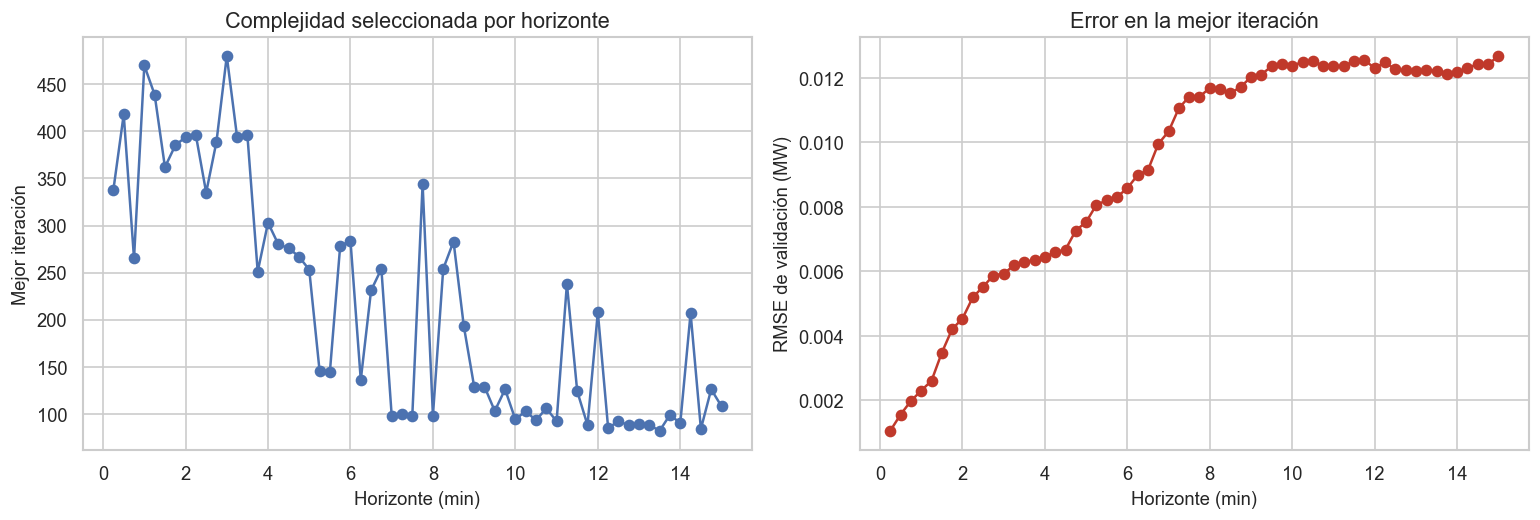

In [13]:
# ============================================================
# 13. DIAGNÓSTICO DE PARADA TEMPRANA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(training_history["lead_min"], training_history["best_iteration"], marker="o")
axes[0].set(xlabel="Horizonte (min)", ylabel="Mejor iteración", title="Complejidad seleccionada por horizonte")
axes[1].plot(training_history["lead_min"], training_history["best_val_rmse"], marker="o", color="#C0392B")
axes[1].set(xlabel="Horizonte (min)", ylabel="RMSE de validación (MW)", title="Error en la mejor iteración")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_early_stopping.png", bbox_inches="tight")
plt.show()


## 5. Predicción, intervalos empíricos y métricas

El pronóstico puntual de XGBoost no produce cuantiles de forma nativa. Para aportar un análisis exploratorio de incertidumbre se calculan, por horizonte, los percentiles 10 y 90 de los residuos de validación y se trasladan al test. Estos intervalos no constituyen una garantía formal de cobertura y deben presentarse separados de los cuantiles nativos del TFT.

MAPE se calcula únicamente donde `|y| > 10⁻⁹`; en esta aplicación no sustituye a MAE/RMSE. R² se reporta como descriptor complementario y puede ser negativo fuera de muestra.


In [14]:
# ============================================================
# 14. PREDICCIONES MULTIHORIZONTE
# ============================================================

def predecir_multihorizonte(X):
    output = np.column_stack([model.predict(X) for model in models])
    return np.asarray(output, dtype=np.float32)

inference_start = time.time()
pred_val = predecir_multihorizonte(X_val)
val_inference_seconds = time.time() - inference_start
inference_start = time.time()
pred_test = predecir_multihorizonte(X_test)
test_inference_seconds = time.time() - inference_start

assert pred_val.shape == Y_val.shape and pred_test.shape == Y_test.shape
assert np.isfinite(pred_val).all() and np.isfinite(pred_test).all()
print(f"Inferencia validation: {val_inference_seconds:.3f} s")
print(f"Inferencia test: {test_inference_seconds:.3f} s")


Inferencia validation: 2.426 s
Inferencia test: 2.362 s


In [15]:
# ============================================================
# 15. INTERVALOS EMPÍRICOS P10-P90 CALIBRADOS EN VALIDACIÓN
# ============================================================

residual_val = Y_val - pred_val
residual_q10 = np.quantile(residual_val, INTERVAL_QUANTILES[0], axis=0).astype(np.float32)
residual_q90 = np.quantile(residual_val, INTERVAL_QUANTILES[1], axis=0).astype(np.float32)
pred_test_p10 = pred_test + residual_q10[None, :]
pred_test_p90 = pred_test + residual_q90[None, :]
assert np.all(pred_test_p10 <= pred_test_p90)

def pinball_loss(y_true, y_pred, quantile):
    error = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.maximum(quantile * error, (quantile - 1) * error)))

interval_coverage = float(np.mean((Y_test >= pred_test_p10) & (Y_test <= pred_test_p90)))
interval_width = float(np.mean(pred_test_p90 - pred_test_p10))
interval_summary = pd.DataFrame([{
    "dataset": "TEST",
    "method": "residual_quantiles_from_validation",
    "nominal_coverage": 0.80,
    "empirical_coverage": interval_coverage,
    "mean_width_MW": interval_width,
    "pinball_P10": pinball_loss(Y_test, pred_test_p10, 0.10),
    "pinball_P90": pinball_loss(Y_test, pred_test_p90, 0.90),
}])
display(interval_summary)


,dataset,method,nominal_coverage,empirical_coverage,mean_width_MW,pinball_P10,pinball_P90
0,TEST,residual_quantiles_from_validation,0.800000,0.752894,0.012787,0.001447,0.001246


In [16]:
# ============================================================
# 16. FORMATO LONG SIN PÉRDIDA DE PASOS DEL HORIZONTE
# ============================================================

def crear_eval_long(origins, y_true, y_pred, dataset_name, p10=None, p90=None):
    n_forecasts = len(origins)
    lead_steps = np.tile(np.arange(1, HORIZON + 1), n_forecasts)
    origin_repeated = np.repeat(origins, HORIZON)
    target_positions = origin_repeated + lead_steps - 1
    persistence = np.repeat(values_target[origins - 1], HORIZON)
    result = pd.DataFrame({
        "dataset": dataset_name,
        "forecast_id": np.repeat(np.arange(n_forecasts), HORIZON),
        "forecast_origin": np.repeat(time_index[origins].to_numpy(), HORIZON),
        "timestamp": time_index[target_positions].to_numpy(),
        "lead_step": lead_steps,
        "lead_min": lead_steps * MODEL_STEP_SECONDS / 60.0,
        "y_true": y_true.reshape(-1),
        "y_pred": y_pred.reshape(-1),
        "y_persistence": persistence,
    })
    if p10 is not None and p90 is not None:
        result["y_pred_p10"] = p10.reshape(-1)
        result["y_pred_p90"] = p90.reshape(-1)
    assert len(result) == n_forecasts * HORIZON
    return result

eval_val = crear_eval_long(val_origins, Y_val, pred_val, "VALIDATION")
eval_test = crear_eval_long(test_origins, Y_test, pred_test, "TEST", pred_test_p10, pred_test_p90)

assert len(eval_val) == len(val_origins) * HORIZON
assert len(eval_test) == len(test_origins) * HORIZON
assert eval_val["forecast_id"].nunique() == len(val_origins)
assert eval_test["forecast_id"].nunique() == len(test_origins)
assert eval_test.groupby("forecast_id").size().eq(HORIZON).all()
assert (eval_test["timestamp"] >= eval_test["forecast_origin"]).all()
display(eval_test.head())


,dataset,forecast_id,forecast_origin,timestamp,lead_step,lead_min,y_true,y_pred,y_persistence,y_pred_p10,y_pred_p90
0,TEST,0,2026-08-24 08:13:15,2026-08-24 08:13:15,1,0.250000,2.348270,2.348409,2.348210,2.347914,2.349020
1,TEST,0,2026-08-24 08:13:15,2026-08-24 08:13:30,2,0.500000,2.348500,2.348368,2.348210,2.347471,2.349641
2,TEST,0,2026-08-24 08:13:15,2026-08-24 08:13:45,3,0.750000,2.348729,2.348406,2.348210,2.346815,2.350162
3,TEST,0,2026-08-24 08:13:15,2026-08-24 08:14:00,4,1.000000,2.348959,2.348319,2.348210,2.346317,2.350554
4,TEST,0,2026-08-24 08:13:15,2026-08-24 08:14:15,5,1.250000,2.349189,2.348428,2.348210,2.345809,2.351307


In [17]:
# ============================================================
# 17. MÉTRICAS DETERMINÍSTICAS GLOBALES Y POR HORIZONTE
# ============================================================

def metricas_basicas(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    error = y_true - y_pred
    mape_mask = np.abs(y_true) > 1e-9
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAPE_pct": float(np.mean(np.abs(error[mape_mask] / y_true[mape_mask])) * 100) if mape_mask.any() else np.nan,
        "R2": float(r2_score(y_true, y_pred)),
    }

def tabla_global(eval_df):
    rows = []
    for model_name, column in (("XGBoost", "y_pred"), ("Persistencia", "y_persistence")):
        rows.append({"dataset": eval_df["dataset"].iloc[0], "modelo": model_name, **metricas_basicas(eval_df["y_true"], eval_df[column])})
    return pd.DataFrame(rows)

def tabla_por_horizonte(eval_df):
    rows = []
    for lead_step, subset in eval_df.groupby("lead_step", sort=True):
        mx = metricas_basicas(subset["y_true"], subset["y_pred"])
        mp = metricas_basicas(subset["y_true"], subset["y_persistence"])
        rows.append({
            "dataset": subset["dataset"].iloc[0],
            "lead_step": int(lead_step), "lead_min": float(subset["lead_min"].iloc[0]),
            **{f"{key}_XGBOOST": value for key, value in mx.items()},
            **{f"{key}_PERSISTENCIA": value for key, value in mp.items()},
            "MEJORA_MAE_pct": 100 * (mp["MAE"] - mx["MAE"]) / mp["MAE"] if mp["MAE"] > 0 else np.nan,
        })
    return pd.DataFrame(rows)

metrics_global = pd.concat([tabla_global(eval_val), tabla_global(eval_test)], ignore_index=True)
metrics_by_horizon = pd.concat([tabla_por_horizonte(eval_val), tabla_por_horizonte(eval_test)], ignore_index=True)
metrics_horizon_final = metrics_by_horizon.loc[metrics_by_horizon["lead_step"].eq(HORIZON)].copy()
assert len(metrics_horizon_final) == 2
assert np.allclose(metrics_horizon_final["lead_min"], HORIZON_MINUTES)
display(metrics_global)
print(f"Métricas exactamente al horizonte final: {HORIZON_MINUTES:g} min")
display(metrics_horizon_final)


,dataset,modelo,MAE,RMSE,MAPE_pct,R2
0,VALIDATION,XGBoost,0.004984,0.009948,0.216102,0.856430
1,VALIDATION,Persistencia,0.004935,0.010557,0.213299,0.838342
2,TEST,XGBoost,0.005115,0.008055,0.223616,0.880769
3,TEST,Persistencia,0.004978,0.007862,0.216878,0.886402


Métricas exactamente al horizonte final: 15 min


,dataset,lead_step,lead_min,MAE_XGBOOST,RMSE_XGBOOST,MAPE_pct_XGBOOST,R2_XGBOOST,MAE_PERSISTENCIA,RMSE_PERSISTENCIA,MAPE_pct_PERSISTENCIA,R2_PERSISTENCIA,MEJORA_MAE_pct
59,VALIDATION,60,15.000000,0.007278,0.012682,0.315747,0.757921,0.007636,0.013924,0.330407,0.708179,4.690735
119,TEST,60,15.000000,0.008193,0.011937,0.358161,0.737092,0.008361,0.011904,0.364149,0.738536,2.014505


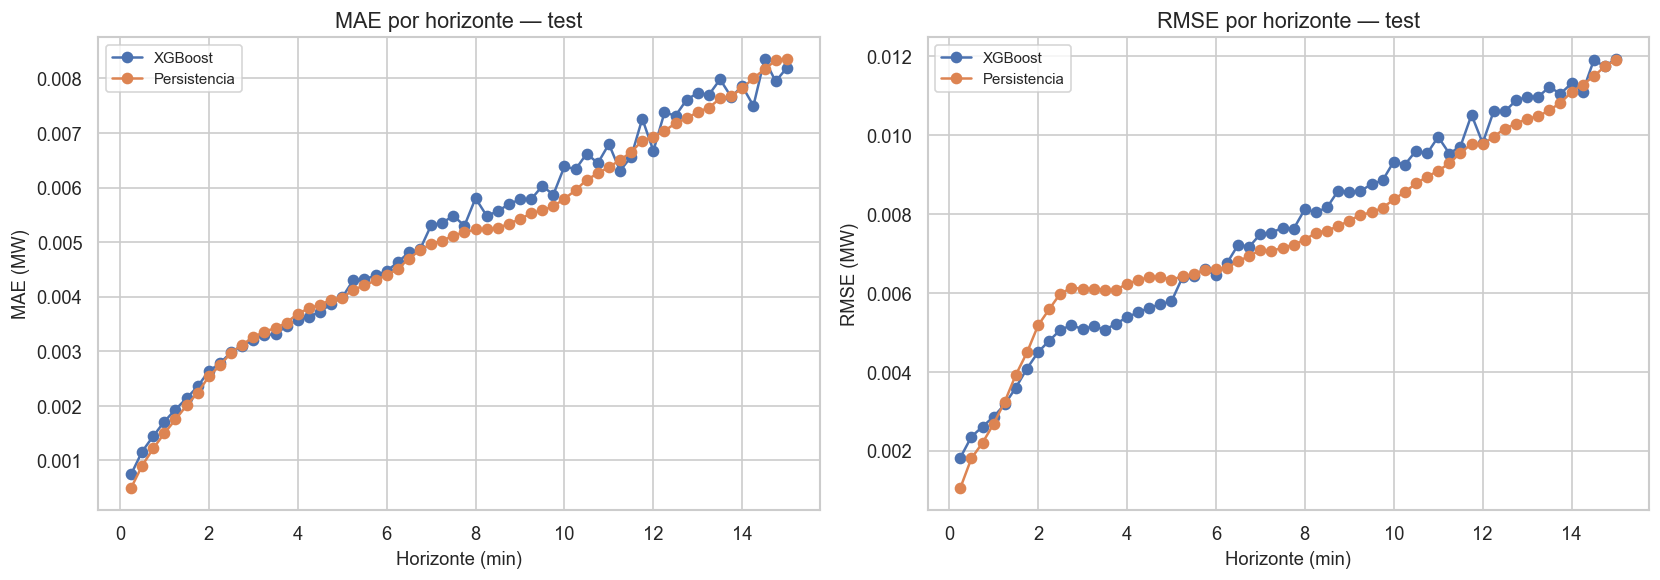

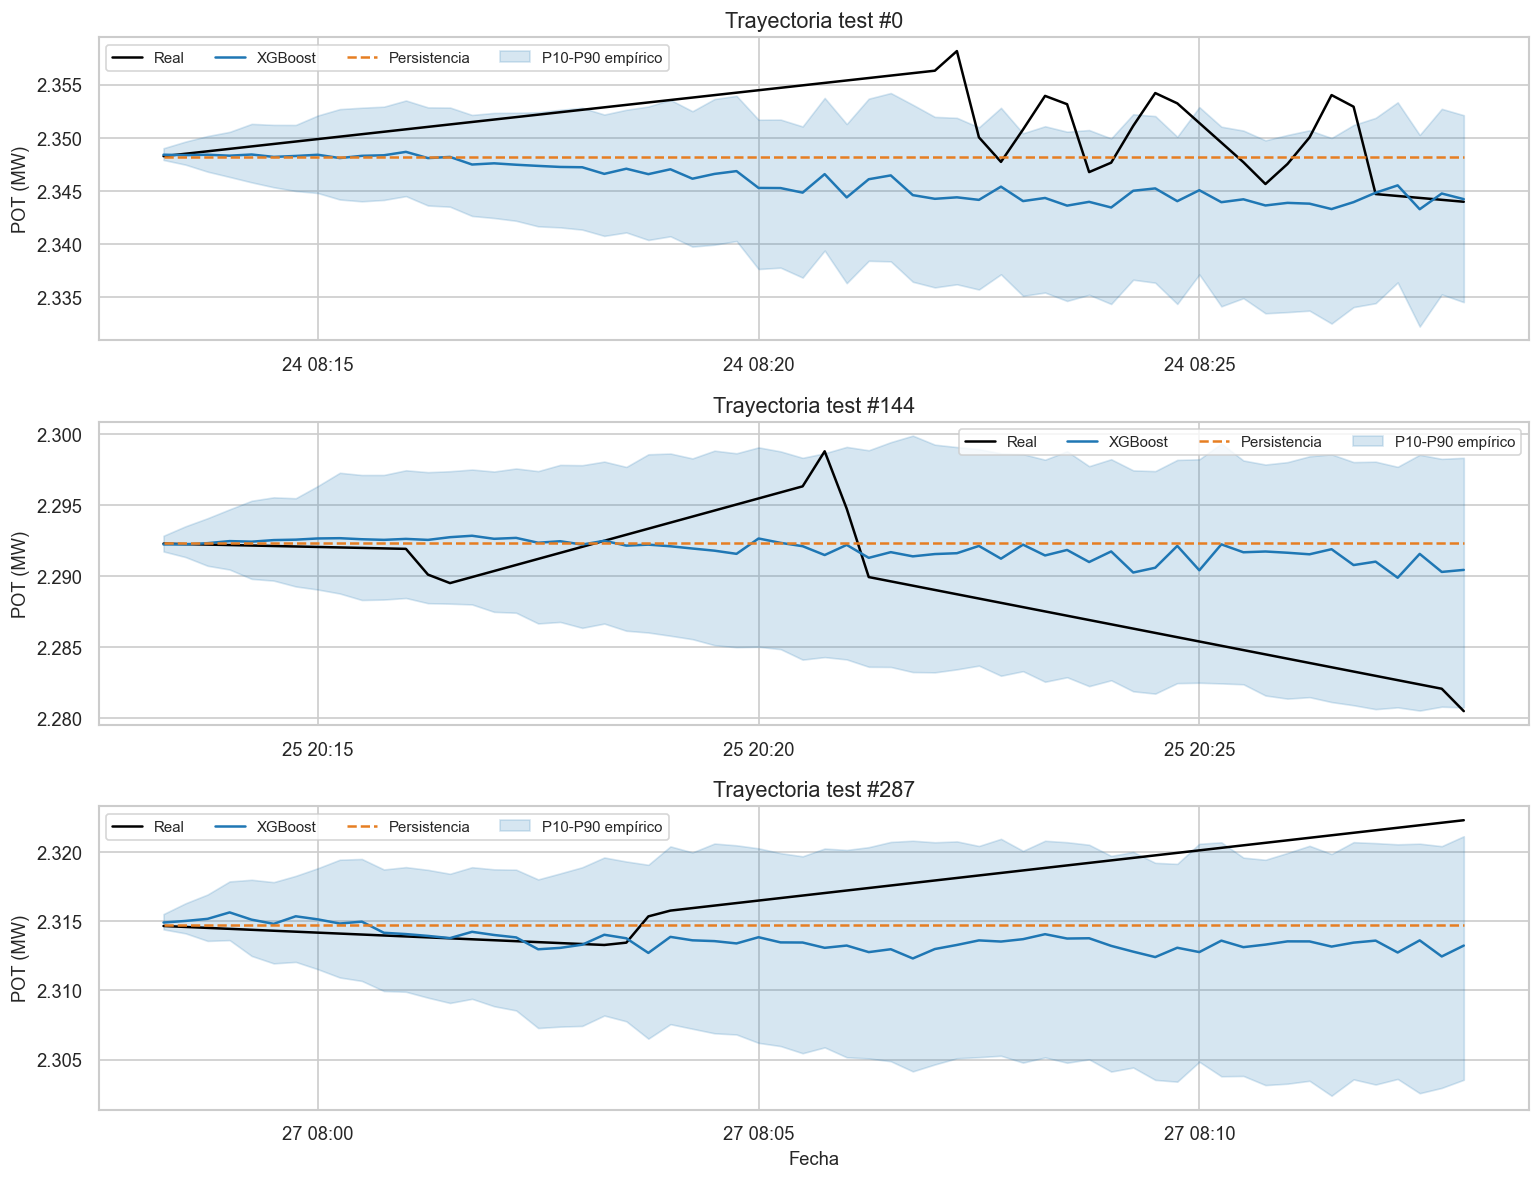

In [18]:
# ============================================================
# 18. CURVAS DE ERROR Y TRAYECTORIAS REPRESENTATIVAS
# ============================================================

test_h = metrics_by_horizon.query("dataset == 'TEST'")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(test_h["lead_min"], test_h["MAE_XGBOOST"], marker="o", label="XGBoost")
axes[0].plot(test_h["lead_min"], test_h["MAE_PERSISTENCIA"], marker="o", label="Persistencia")
axes[0].set(xlabel="Horizonte (min)", ylabel="MAE (MW)", title="MAE por horizonte — test")
axes[0].legend()
axes[1].plot(test_h["lead_min"], test_h["RMSE_XGBOOST"], marker="o", label="XGBoost")
axes[1].plot(test_h["lead_min"], test_h["RMSE_PERSISTENCIA"], marker="o", label="Persistencia")
axes[1].set(xlabel="Horizonte (min)", ylabel="RMSE (MW)", title="RMSE por horizonte — test")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_error_por_horizonte_test.png", bbox_inches="tight")
plt.show()

representative_ids = [0, len(test_origins) // 2, len(test_origins) - 1]
fig, axes = plt.subplots(len(representative_ids), 1, figsize=(13, 10))
for axis, forecast_id in zip(axes, representative_ids):
    sub = eval_test.query("forecast_id == @forecast_id")
    axis.plot(sub["timestamp"], sub["y_true"], label="Real", color="black")
    axis.plot(sub["timestamp"], sub["y_pred"], label="XGBoost", color="#1F77B4")
    axis.plot(sub["timestamp"], sub["y_persistence"], label="Persistencia", linestyle="--", color="#E67E22")
    axis.fill_between(
        sub["timestamp"].to_numpy(),
        sub["y_pred_p10"].to_numpy(dtype=float),
        sub["y_pred_p90"].to_numpy(dtype=float),
        alpha=0.18, color="#1F77B4", label="P10-P90 empírico"
    )
    axis.set(title=f"Trayectoria test #{forecast_id}", ylabel="POT (MW)")
    axis.legend(ncol=4)
axes[-1].set_xlabel("Fecha")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_trayectorias_test.png", bbox_inches="tight")
plt.show()


## 6. Robustez, eventos e interpretabilidad

La comparación con persistencia se somete a un *bootstrap* pareado por trayectoria completa, respetando la dependencia interna de los `HORIZON` pasos. El análisis de umbral es secundario y define el evento operativo como `POT < 2.28 MW`. La importancia por ganancia y la permutación agrupada describen relevancia predictiva; no demuestran causalidad.


In [19]:
# ============================================================
# 19. BOOTSTRAP PAREADO POR TRAYECTORIA
# ============================================================

path_errors = eval_test.assign(
    abs_xgb=lambda d: np.abs(d["y_true"] - d["y_pred"]),
    abs_persistence=lambda d: np.abs(d["y_true"] - d["y_persistence"]),
).groupby("forecast_id")[["abs_xgb", "abs_persistence"]].mean()

rng = np.random.default_rng(SEED)
differences = np.empty(BOOTSTRAP_REPETITIONS, dtype=float)
path_values = path_errors.to_numpy()
for iteration in range(BOOTSTRAP_REPETITIONS):
    sampled = path_values[rng.integers(0, len(path_values), size=len(path_values))]
    differences[iteration] = np.mean(sampled[:, 1] - sampled[:, 0])

bootstrap_summary = pd.DataFrame([{
    "comparison": "MAE_persistencia - MAE_XGBoost",
    "mean_difference_MW": float(differences.mean()),
    "ci95_low_MW": float(np.quantile(differences, 0.025)),
    "ci95_high_MW": float(np.quantile(differences, 0.975)),
    "probability_xgb_better": float(np.mean(differences > 0)),
    "bootstrap_unit": f"forecast_path_{HORIZON}_steps_{HORIZON_TAG}",
    "forecast_paths": int(len(path_values)),
    "repetitions": BOOTSTRAP_REPETITIONS,
}])
display(bootstrap_summary)


,comparison,mean_difference_MW,ci95_low_MW,ci95_high_MW,probability_xgb_better,bootstrap_unit,forecast_paths,repetitions
0,MAE_persistencia - MAE_XGBoost,-0.000132,-0.000609,0.000310,0.298500,forecast_path_60_steps_15min,288,2000


In [20]:
# ============================================================
# 20. DESEMPEÑO EN EVENTOS BAJO EL UMBRAL OPERATIVO
# ============================================================

def event_metrics(y_true, y_score, threshold):
    actual = np.asarray(y_true) < threshold
    predicted = np.asarray(y_score) < threshold
    precision, recall, f1, _ = precision_recall_fscore_support(actual, predicted, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[False, True]).ravel()
    return {
        "threshold_MW": threshold, "direction": "POT < threshold", "n_events_real": int(actual.sum()),
        "precision": precision, "recall": recall, "F1": f1,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

event_summary = pd.DataFrame([
    {"modelo": "XGBoost", **event_metrics(eval_test["y_true"], eval_test["y_pred"], POWER_DANGER_THRESHOLD)},
    {"modelo": "Persistencia", **event_metrics(eval_test["y_true"], eval_test["y_persistence"], POWER_DANGER_THRESHOLD)},
])
display(event_summary)


,modelo,threshold_MW,direction,n_events_real,precision,recall,F1,TN,FP,FN,TP
0,XGBoost,2.280000,POT < threshold,5905,0.876026,0.686876,0.770005,10801,574,1849,4056
1,Persistencia,2.280000,POT < threshold,5905,0.841582,0.846571,0.844069,10434,941,906,4999


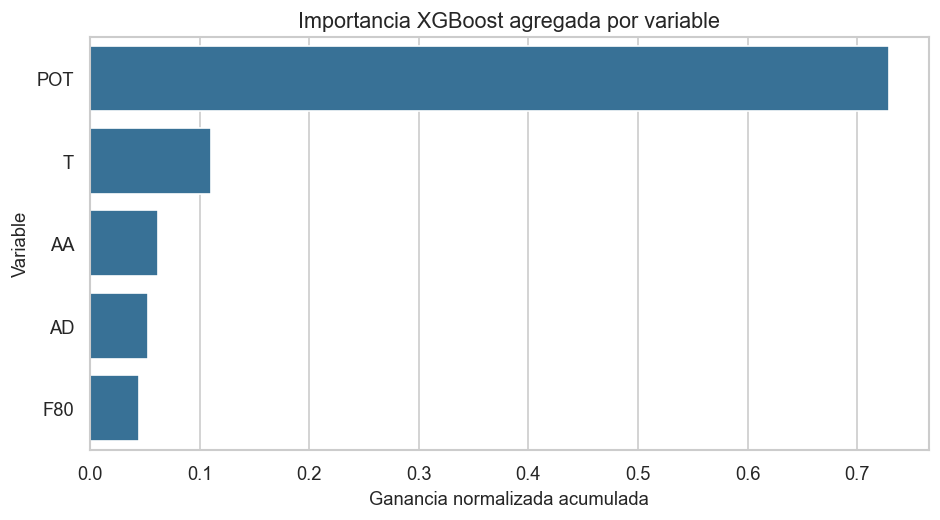

,variable,importance_mean
3,POT,0.728846
4,T,0.110788
0,AA,0.062139
1,AD,0.053213
2,F80,0.045015


In [21]:
# ============================================================
# 21. IMPORTANCIA NATIVA AGREGADA SOBRE LOS MODELOS DIRECTOS
# ============================================================

native_matrix = np.vstack([model.feature_importances_ for model in models])
native_importance = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance_mean": native_matrix.mean(axis=0),
    "importance_std": native_matrix.std(axis=0),
})
native_importance["variable"] = native_importance["feature"].str.extract(r"^(.+)_lag_\d+$")[0]
native_importance["lag"] = native_importance["feature"].str.extract(r"_lag_(\d+)$")[0].astype(int)
native_by_variable = native_importance.groupby("variable", as_index=False)["importance_mean"].sum().sort_values("importance_mean", ascending=False)

fig, axis = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=native_by_variable, x="importance_mean", y="variable", ax=axis, color="#2874A6")
axis.set(title="Importancia XGBoost agregada por variable", xlabel="Ganancia normalizada acumulada", ylabel="Variable")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_importancia_nativa.png", bbox_inches="tight")
plt.show()
display(native_by_variable)


,variable,delta_rmse_mean,delta_rmse_std
3,POT,0.023158,0.000613
4,T,0.000257,0.000219
0,AA,0.000240,0.000067
1,AD,-0.000011,0.000009
2,F80,-0.000015,0.000007


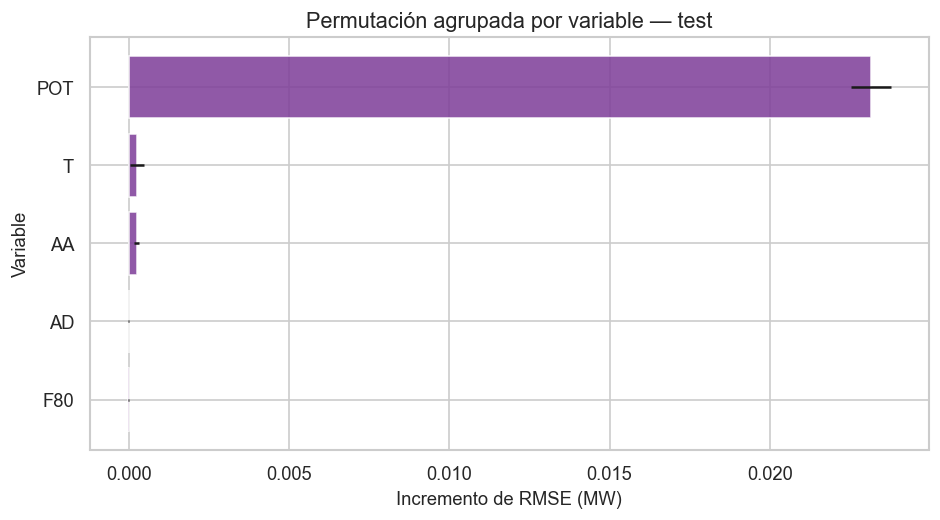

In [22]:
# ============================================================
# 22. IMPORTANCIA POR PERMUTACIÓN AGRUPADA EN TEST
# ============================================================

baseline_rmse = float(np.sqrt(np.mean((Y_test - pred_test) ** 2)))
permutation_rows = []
rng = np.random.default_rng(SEED)

# Cada variable ocupa una columna cada len(INPUT_COLS) posiciones.
for variable_index, variable in enumerate(INPUT_COLS):
    columns = np.arange(variable_index, X_test.shape[1], len(INPUT_COLS))
    for repetition in range(PERMUTATION_REPEATS):
        X_permuted = X_test.copy()
        row_order = rng.permutation(len(X_permuted))
        X_permuted[:, columns] = X_permuted[row_order][:, columns]
        permuted_pred = predecir_multihorizonte(X_permuted)
        permuted_rmse = float(np.sqrt(np.mean((Y_test - permuted_pred) ** 2)))
        permutation_rows.append({
            "variable": variable, "repeat": repetition + 1,
            "baseline_rmse": baseline_rmse, "permuted_rmse": permuted_rmse,
            "delta_rmse": permuted_rmse - baseline_rmse,
        })

permutation_importance = pd.DataFrame(permutation_rows)
permutation_summary = permutation_importance.groupby("variable", as_index=False).agg(
    delta_rmse_mean=("delta_rmse", "mean"),
    delta_rmse_std=("delta_rmse", "std"),
).sort_values("delta_rmse_mean", ascending=False)
display(permutation_summary)

fig, axis = plt.subplots(figsize=(8, 4.5))
axis.barh(permutation_summary["variable"], permutation_summary["delta_rmse_mean"], xerr=permutation_summary["delta_rmse_std"], color="#7D3C98", alpha=0.85)
axis.invert_yaxis()
axis.set(title="Permutación agrupada por variable — test", xlabel="Incremento de RMSE (MW)", ylabel="Variable")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_permutacion_agrupada.png", bbox_inches="tight")
plt.show()


## 7. Exportación reproducible

Se guardan modelos, predicciones, métricas, configuración, versiones y figuras. Estos artefactos son los que deben devolverse para redactar los capítulos de resultados, discusión y conclusiones. No basta con una captura de pantalla: los CSV permiten comprobar cada cifra y construir tablas homogéneas entre modelos.


In [23]:
# ============================================================
# 23. GUARDADO DE MODELOS, TABLAS Y METADATOS
# ============================================================

for index, model in enumerate(models, start=1):
    model.save_model(MODEL_DIR / f"xgboost_lead_{index:02d}.json")
joblib.dump(models, MODEL_DIR / f"xgboost_{HORIZON}_regresores.joblib", compress=3)

tables = {
    "dataset_audit.csv": pd.DataFrame([dataset_audit]),
    "split_table.csv": split_table,
    "origin_summary.csv": origin_summary,
    "training_history.csv": training_history,
    "predictions_validation_long.csv": eval_val,
    "predictions_test_long.csv": eval_test,
    "metrics_global.csv": metrics_global,
    "metrics_by_horizon.csv": metrics_by_horizon,
    "metrics_horizon_final.csv": metrics_horizon_final,
    "interval_summary.csv": interval_summary,
    "bootstrap_summary.csv": bootstrap_summary,
    "event_summary.csv": event_summary,
    "native_importance_all_lags.csv": native_importance,
    "native_importance_by_variable.csv": native_by_variable,
    "permutation_importance_repeats.csv": permutation_importance,
    "permutation_importance_summary.csv": permutation_summary,
}
for filename, table in tables.items():
    table.to_csv(TABLE_DIR / filename, index=False)

environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "xgboost": xgb.__version__,
    "sklearn": __import__("sklearn").__version__,
    "joblib": joblib.__version__,
}
with open(ARTIFACT_DIR / "experiment_config.json", "w", encoding="utf-8") as stream:
    json.dump(experiment_config, stream, indent=2, ensure_ascii=False, default=str)
with open(ARTIFACT_DIR / "environment.json", "w", encoding="utf-8") as stream:
    json.dump(environment, stream, indent=2, ensure_ascii=False)

def file_sha256(path):
    return sha256_file(path)

manifest_rows = []
for path in sorted(ARTIFACT_DIR.rglob("*")):
    if path.is_file() and path.name != "manifest.csv":
        manifest_rows.append({
            "relative_path": str(path.relative_to(ARTIFACT_DIR)),
            "bytes": path.stat().st_size,
            "sha256": file_sha256(path),
        })
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(ARTIFACT_DIR / "manifest.csv", index=False)
print(f"Artefactos guardados en: {ARTIFACT_DIR.resolve()}")
display(manifest)


Artefactos guardados en: C:\Users\jgomeze\Documents\woody\Py\resultados_xgboost_15min_final


,relative_path,bytes,sha256
0,environment.json,243,bc26d0d4c5c8dd143632af1185935d5c44915b804826f6...
1,experiment_config.json,769,117d1a0376be6799e99d70e8abc96997acf6953caf877f...
2,figuras\01_series_temporales.png,837198,cc48960e87fa41ce86a9013af1254413d5fdcbfa9cfbf1...
3,figuras\02_early_stopping.png,289905,1bcb3b75844a9072c232aadd66173a396b51cdcbaf2968...
4,figuras\03_error_por_horizonte_test.png,314499,0879c7bd5c240f63db36a6d6dc6fa2e00effbaa1078ecf...
...,...,...,...
81,tablas\permutation_importance_summary.csv,285,dc56e8052065bf642d8ae4241f4c498785b355fd5ec1c6...
82,tablas\predictions_test_long.csv,1833227,011d42dba6e72d374d45cb9d1cbf322ad3f76ffc54513d...
83,tablas\predictions_validation_long.csv,1599098,66e83fd77e3c9072ae0fcdada57180f670784942ca9aa4...
84,tablas\split_table.csv,192,7711e4c4da714b7d384501df356912395a87b89a2c0248...


In [24]:
# ============================================================
# 24. RESUMEN FINAL PARA LA REDACCIÓN DEL TFM
# ============================================================

global_test = metrics_global.query("dataset == 'TEST'").set_index("modelo")
final_horizon_test = metrics_horizon_final.query("dataset == 'TEST'").iloc[0]
final_summary = {
    "dataset_sha256": DATASET_SHA256,
    "model": f"XGBoost direct, {HORIZON} regressors",
    "horizon_steps": HORIZON,
    "horizon_minutes": HORIZON_MINUTES,
    "rolling_stride_steps": ROLLING_STRIDE,
    "train_origins": len(train_origins),
    "validation_forecast_paths": len(val_origins),
    "test_forecast_paths": len(test_origins),
    "test_MAE_XGBoost_MW": float(global_test.loc["XGBoost", "MAE"]),
    "test_RMSE_XGBoost_MW": float(global_test.loc["XGBoost", "RMSE"]),
    "test_MAPE_XGBoost_pct": float(global_test.loc["XGBoost", "MAPE_pct"]),
    "test_R2_XGBoost": float(global_test.loc["XGBoost", "R2"]),
    "test_MAE_persistence_MW": float(global_test.loc["Persistencia", "MAE"]),
    "final_horizon_MAE_XGBoost_MW": float(final_horizon_test["MAE_XGBOOST"]),
    "final_horizon_RMSE_XGBoost_MW": float(final_horizon_test["RMSE_XGBOOST"]),
    "final_horizon_R2_XGBoost": float(final_horizon_test["R2_XGBOOST"]),
    "final_horizon_MAE_persistence_MW": float(final_horizon_test["MAE_PERSISTENCIA"]),
    "empirical_interval_coverage": interval_coverage,
    "empirical_interval_width_MW": interval_width,
    "bootstrap_ci95_MW": [
        float(bootstrap_summary.loc[0, "ci95_low_MW"]),
        float(bootstrap_summary.loc[0, "ci95_high_MW"]),
    ],
    "training_minutes": training_seconds_total / 60,
    "test_inference_seconds": test_inference_seconds,
}
with open(ARTIFACT_DIR / "final_summary.json", "w", encoding="utf-8") as stream:
    json.dump(final_summary, stream, indent=2, ensure_ascii=False)
print(json.dumps(final_summary, indent=2, ensure_ascii=False))
print(
    f"\nCORRIDA FINALIZADA PARA {HORIZON_MINUTES:g} MIN. "
    f"Comprima {ARTIFACT_DIR.name} y consérvela junto con el notebook ejecutado."
)


{
  "dataset_sha256": "13ab2cc37de733a14a352a7cd8c7b1b681499e4b8470d360205a5e75b84a7cf1",
  "model": "XGBoost direct, 60 regressors",
  "horizon_steps": 60,
  "horizon_minutes": 15.0,
  "rolling_stride_steps": 60,
  "train_origins": 113454,
  "validation_forecast_paths": 288,
  "test_forecast_paths": 288,
  "test_MAE_XGBoost_MW": 0.005115289834362489,
  "test_RMSE_XGBoost_MW": 0.00805466372871319,
  "test_MAPE_XGBoost_pct": 0.2236164127220317,
  "test_R2_XGBoost": 0.8807690600336577,
  "test_MAE_persistence_MW": 0.0049784133003817664,
  "final_horizon_MAE_XGBoost_MW": 0.008192567361725701,
  "final_horizon_RMSE_XGBoost_MW": 0.011936669376552743,
  "final_horizon_R2_XGBoost": 0.737091849971771,
  "final_horizon_MAE_persistence_MW": 0.008361000153753493,
  "empirical_interval_coverage": 0.7528935185185185,
  "empirical_interval_width_MW": 0.012787186540663242,
  "bootstrap_ci95_MW": [
    -0.0006093202464398928,
    0.0003098505527304946
  ],
  "training_minutes": 21.386787168184917,
  "

## 8. Criterios de interpretación y limitaciones

1. **Generalización temporal.** Las métricas de test representan exclusivamente los últimos tres días del archivo.
2. **Comparación justa.** TFT, XGBoost y ARIMAX deben usar el mismo `HORIZON`, `ROLLING_STRIDE`, los mismos timestamps y el mismo benchmark.
3. **Persistencia.** En señales de alta inercia es un referente exigente; no superarla es un resultado científico válido.
4. **Incertidumbre.** P10–P90 es una aproximación residual calibrada en validación, no una salida probabilística nativa de XGBoost.
5. **Importancia.** La ganancia y la permutación miden asociación predictiva condicionada al modelo; no identifican causas físicas.
6. **Umbral operativo.** `2.28 MW` debe confirmarse como criterio de planta.
7. **Cobertura temporal.** Si la longitud de la partición no es múltiplo del avance, `origin_summary.csv` deja constancia de la cobertura efectiva.

### Referencias metodológicas

- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785–794. https://doi.org/10.1145/2939672.2939785
- Bergmeir, C., Hyndman, R. J., & Koo, B. (2018). A note on the validity of cross-validation for evaluating autoregressive time series prediction. *Computational Statistics & Data Analysis, 120*, 70–83. https://doi.org/10.1016/j.csda.2017.11.003
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
